# Session 4 Machine Learning Case Studies

**Learning goals:**

- build and evaluate regression models for California housing and Diabetes data
- build and evaluate a multi-output regression model for Linnerud exercise and physical measurements
- build and evaluate classification models for MNIST digit images
- cluster Wine samples without using their known classes during training
- select a K-means cluster count using silhouette score
- interpret clusters in the original feature space without PCA
- compare completed model workflows fairly

**Prerequisites:**

- completion of [Session 3](<Session3 Essentials of ML and DL Technologies.ipynb>)
- basic Python, pandas, NumPy and Matplotlib
- familiarity with `scikit-learn` estimators, pipelines and train/test splits
- the local files `sample_data/california_housing.csv` and `sample_data/mnist_train_small.csv`

This session develops five end-to-end machine learning case studies covering single-output regression, multi-output regression, classification and clustering. Each case study presents data import and preparation before the model workflows. Broader AI applications continue in [Session 5: AI Opportunities](<Session5 AI Opportunities.ipynb>).


## Outline

1. California Housing regression
   - linear regression
   - multilayer perceptron regression
2. Diabetes regression
   - predict a quantitative disease-progression measure with Random Forest regression
   - build Gradient Boosting regression as a separate workflow
   - build MLP regression with feature and target standardisation
   - compare the three completed regression models
3. Linnerud exercise and physical measurements regression
   - predict Weight, Waist and Pulse together with multi-output Ridge regression
   - evaluate the small dataset with leave-one-out cross-validation
4. MNIST digit classification
   - two multilayer perceptrons
   - histogram gradient boosting
   - K-nearest neighbours
5. Wine clustering
   - load the built-in Wine data
   - select `k` with silhouette score
   - build and visualise K-means without PCA
   - profile clusters and compare with held-out known classes
6. Practice and reflection
7. Common pitfalls and extensions


## 1. Case Study — California Housing Regression

This supervised regression task predicts `median_house_value` from numeric district features. The dataset is imported, cleaned and split once. Each regression model then follows its own complete modelling workflow.


### 1.1 Data Import and Preparation

The text feature is removed for this introductory comparison, and rows with missing values are dropped. An 80/20 split creates one training set and one unseen test set.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
HOUSING_DATA_PATH = "sample_data/california_housing.csv"

# Load the local housing data when it is first used in this case study.
housing_raw = pd.read_csv(HOUSING_DATA_PATH)

# Keep numeric features and remove incomplete rows for this introductory workflow.
housing = housing_raw.drop(columns="ocean_proximity").dropna().reset_index(drop=True)
X_housing = housing.drop(columns="median_house_value")
y_housing = housing["median_house_value"]

# Reserve 20% of rows for an unseen test set; the fixed seed makes the split reproducible.
X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(
    X_housing,
    y_housing,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Original rows: {len(housing_raw):,}")
print(f"Rows after dropping missing values: {len(housing):,}")
print(f"Training shape: {X_house_train.shape}")
print(f"Test shape: {X_house_test.shape}")
housing.head(3)


Original rows: 20,640
Rows after dropping missing values: 20,433
Training shape: (16346, 8)
Test shape: (4087, 8)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0


### 1.2 Model 1 — Linear Regression

This workflow uses linear regression as an interpretable baseline. Standardisation and the estimator are kept in one pipeline so preprocessing is learnt from the training data only.

**Workflow:** construct → fit → predict → evaluate → inspect.


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Chain feature standardisation and linear regression in one reusable estimator.
linear_housing_model = make_pipeline(
    StandardScaler(),
    LinearRegression(),
)

# Fit every pipeline step using the housing training partition only.
linear_housing_model.fit(X_house_train, y_house_train)
linear_housing_predictions = linear_housing_model.predict(X_house_test)

# Summarise absolute error, squared error and explained variation on unseen rows.
linear_housing_mae = mean_absolute_error(y_house_test, linear_housing_predictions)
linear_housing_rmse = np.sqrt(mean_squared_error(y_house_test, linear_housing_predictions))
linear_housing_r2 = r2_score(y_house_test, linear_housing_predictions)

print(f"MAE: ${linear_housing_mae:,.0f}")
print(f"RMSE: ${linear_housing_rmse:,.0f}")
print(f"R-squared: {linear_housing_r2:.4f}")


MAE: $51,373
RMSE: $70,156
R-squared: 0.6401


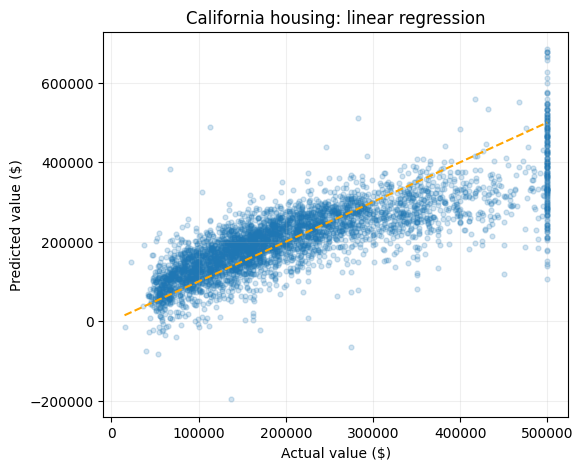

In [3]:
linear_plot_limits = [y_house_test.min(), y_house_test.max()]

# Compare actual and predicted values; the dashed diagonal represents perfect predictions.
plt.figure(figsize=(6, 5))
plt.scatter(y_house_test, linear_housing_predictions, alpha=0.2, s=12)
plt.plot(linear_plot_limits, linear_plot_limits, color="orange", linestyle="--")
plt.xlabel("Actual value ($)")
plt.ylabel("Predicted value ($)")
plt.title("California housing: linear regression")
plt.grid(alpha=0.2)
plt.show()


### 1.3 Model 2 — Multilayer Perceptron Regression

The MLP can learn non-linear relationships. The feature pipeline standardises `X`; `TransformedTargetRegressor` separately standardises `y` during training and converts predictions back to dollars.

**Workflow:** construct → fit → predict → evaluate → inspect.


In [4]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Build a one-hidden-layer MLP and stop early when validation performance stops improving.
mlp_housing_model = TransformedTargetRegressor(
    regressor=make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(32,),
            max_iter=250,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
    ),
    transformer=StandardScaler(),
)

# Train this model independently on the housing training partition.
mlp_housing_model.fit(X_house_train, y_house_train)
mlp_housing_predictions = mlp_housing_model.predict(X_house_test)

# Evaluate this model independently on the unseen housing test partition.
mlp_housing_mae = mean_absolute_error(y_house_test, mlp_housing_predictions)
mlp_housing_rmse = np.sqrt(mean_squared_error(y_house_test, mlp_housing_predictions))
mlp_housing_r2 = r2_score(y_house_test, mlp_housing_predictions)

print(f"MAE: ${mlp_housing_mae:,.0f}")
print(f"RMSE: ${mlp_housing_rmse:,.0f}")
print(f"R-squared: {mlp_housing_r2:.4f}")


MAE: $39,754
RMSE: $57,577
R-squared: 0.7576


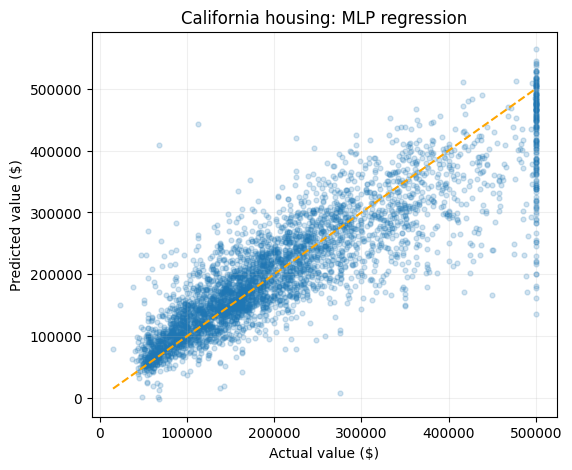

In [5]:
mlp_plot_limits = [y_house_test.min(), y_house_test.max()]

# Inspect the MLP predictions against the same perfect-prediction reference line.
plt.figure(figsize=(6, 5))
plt.scatter(y_house_test, mlp_housing_predictions, alpha=0.2, s=12)
plt.plot(mlp_plot_limits, mlp_plot_limits, color="orange", linestyle="--")
plt.xlabel("Actual value ($)")
plt.ylabel("Predicted value ($)")
plt.title("California housing: MLP regression")
plt.grid(alpha=0.2)
plt.show()


### 1.4 Compare the completed regression workflows

This table compares metrics produced by the two already-completed workflows. It does not rebuild or retrain either model. Lower MAE and RMSE are better; higher R-squared is better.


In [6]:
# Compare stored evaluation results without combining the two training workflows.
housing_results = pd.DataFrame(
    [
        {
            "model": "Linear regression",
            "MAE ($)": linear_housing_mae,
            "RMSE ($)": linear_housing_rmse,
            "R-squared": linear_housing_r2,
        },
        {
            "model": "MLP (one hidden layer)",
            "MAE ($)": mlp_housing_mae,
            "RMSE ($)": mlp_housing_rmse,
            "R-squared": mlp_housing_r2,
        },
    ]
).sort_values("MAE ($)")

housing_results.style.format(
    {"MAE ($)": "${:,.0f}", "RMSE ($)": "${:,.0f}", "R-squared": "{:.4f}"}
)


,model,MAE ($),RMSE ($),R-squared
1,MLP (one hidden layer),"$39,754","$57,577",0.7576
0,Linear regression,"$51,373","$70,156",0.6401


## 2. Case Study — Diabetes Regression

**Problem:** Can baseline clinical measurements predict a quantitative measure of diabetes disease progression one year later?

This case uses scikit-learn's built-in [Diabetes dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html). It contains 442 samples, 10 numeric baseline features and one continuous regression target. The target measures disease progression; it is not a diabetes diagnosis or an individual risk score.


### 2.1 Load, Inspect and Split the Data

The raw feature values are loaded in their original units. A fixed 75/25 split reserves unseen samples for evaluating both tree-based regression methods.


In [7]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

DIABETES_RANDOM_STATE = 42

# Load features in their original units; tree-based models do not require standardisation.
diabetes = load_diabetes(as_frame=True, scaled=False)
X_diabetes = diabetes.data
y_diabetes = diabetes.target

# Reserve 25% of samples for a reproducible, unseen evaluation partition.
X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.25,
    random_state=DIABETES_RANDOM_STATE,
)

print(f"Samples: {X_diabetes.shape[0]}")
print(f"Features: {X_diabetes.shape[1]}")
print(f"Training shape: {X_diabetes_train.shape}")
print(f"Test shape: {X_diabetes_test.shape}")
pd.concat([X_diabetes.head(3), y_diabetes.head(3)], axis=1)


Samples: 442
Features: 10
Training shape: (331, 10)
Test shape: (111, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0


### 2.2 Model 1 — Random Forest Regression

A Random Forest fits many decision trees to different bootstrap samples and averages their numeric predictions. Averaging reduces the instability of relying on one tree, while `min_samples_leaf` limits very small terminal groups.

**Workflow:** construct → fit → predict → evaluate → inspect.


In [8]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Average 300 trees and require at least three training samples in each leaf.
diabetes_rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=DIABETES_RANDOM_STATE,
    n_jobs=-1,
)

# Fit the forest on the training partition and predict the unseen test partition.
diabetes_rf_model.fit(X_diabetes_train, y_diabetes_train)
diabetes_rf_predictions = diabetes_rf_model.predict(X_diabetes_test)

# Evaluate only the predictions produced by the Random Forest workflow.
diabetes_rf_mae = mean_absolute_error(y_diabetes_test, diabetes_rf_predictions)
diabetes_rf_rmse = np.sqrt(mean_squared_error(y_diabetes_test, diabetes_rf_predictions))
diabetes_rf_r2 = r2_score(y_diabetes_test, diabetes_rf_predictions)

print(f"MAE: {diabetes_rf_mae:.2f} target units")
print(f"RMSE: {diabetes_rf_rmse:.2f} target units")
print(f"R-squared: {diabetes_rf_r2:.3f}")


MAE: 42.16 target units
RMSE: 53.14 target units
R-squared: 0.489


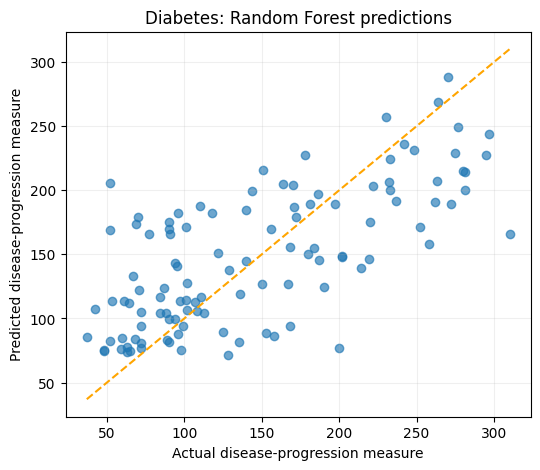

In [9]:
import matplotlib.pyplot as plt

diabetes_rf_plot_min = min(y_diabetes_test.min(), diabetes_rf_predictions.min())
diabetes_rf_plot_max = max(y_diabetes_test.max(), diabetes_rf_predictions.max())

# Compare actual and predicted progression values with a perfect-prediction line.
plt.figure(figsize=(6, 5))
plt.scatter(y_diabetes_test, diabetes_rf_predictions, alpha=0.65)
plt.plot(
    [diabetes_rf_plot_min, diabetes_rf_plot_max],
    [diabetes_rf_plot_min, diabetes_rf_plot_max],
    color="orange",
    linestyle="--",
)
plt.xlabel("Actual disease-progression measure")
plt.ylabel("Predicted disease-progression measure")
plt.title("Diabetes: Random Forest predictions")
plt.grid(alpha=0.2)
plt.show()


### 2.3 Model 2 — Gradient Boosting Regression

Gradient Boosting builds shallow decision trees sequentially. Each new tree focuses on reducing the errors remaining from the current ensemble. A small learning rate makes each tree's contribution more gradual.

**Workflow:** construct → fit → predict → evaluate → inspect.


In [10]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Build shallow trees sequentially and control each tree's contribution.
diabetes_gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=DIABETES_RANDOM_STATE,
)

# Fit and predict as a workflow independent of the Random Forest model.
diabetes_gb_model.fit(X_diabetes_train, y_diabetes_train)
diabetes_gb_predictions = diabetes_gb_model.predict(X_diabetes_test)

# Evaluate only the predictions produced by the Gradient Boosting workflow.
diabetes_gb_mae = mean_absolute_error(y_diabetes_test, diabetes_gb_predictions)
diabetes_gb_rmse = np.sqrt(mean_squared_error(y_diabetes_test, diabetes_gb_predictions))
diabetes_gb_r2 = r2_score(y_diabetes_test, diabetes_gb_predictions)

print(f"MAE: {diabetes_gb_mae:.2f} target units")
print(f"RMSE: {diabetes_gb_rmse:.2f} target units")
print(f"R-squared: {diabetes_gb_r2:.3f}")


MAE: 43.13 target units
RMSE: 55.43 target units
R-squared: 0.444


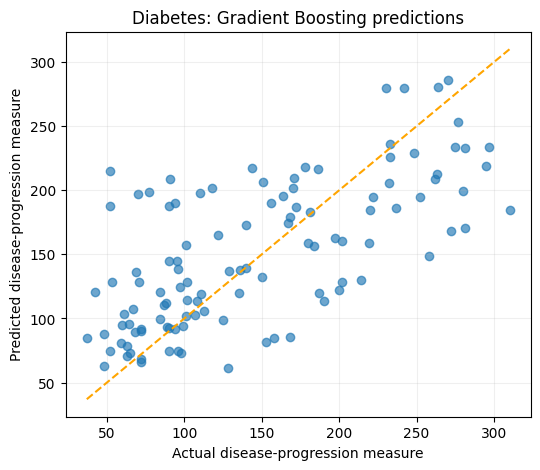

In [11]:
import matplotlib.pyplot as plt

diabetes_gb_plot_min = min(y_diabetes_test.min(), diabetes_gb_predictions.min())
diabetes_gb_plot_max = max(y_diabetes_test.max(), diabetes_gb_predictions.max())

# Compare Gradient Boosting predictions with the perfect-prediction reference line.
plt.figure(figsize=(6, 5))
plt.scatter(y_diabetes_test, diabetes_gb_predictions, alpha=0.65)
plt.plot(
    [diabetes_gb_plot_min, diabetes_gb_plot_max],
    [diabetes_gb_plot_min, diabetes_gb_plot_max],
    color="orange",
    linestyle="--",
)
plt.xlabel("Actual disease-progression measure")
plt.ylabel("Predicted disease-progression measure")
plt.title("Diabetes: Gradient Boosting predictions")
plt.grid(alpha=0.2)
plt.show()


### 2.4 Model 3 — Multilayer Perceptron Regression

An MLP can learn non-linear relationships by combining weighted inputs through hidden layers and activation functions. Unlike the tree-based methods, neural networks are sensitive to numeric scale. The pipeline standardises the features, while `TransformedTargetRegressor` standardises the target during training and converts predictions back to the original target scale.

**Workflow:** construct → fit → predict → evaluate → inspect.


In [12]:
import numpy as np
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Standardise features and train a two-hidden-layer neural network with early stopping.
diabetes_mlp_model = TransformedTargetRegressor(
    regressor=make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(32, 16),
            alpha=0.01,
            max_iter=1_000,
            early_stopping=True,
            n_iter_no_change=30,
            random_state=DIABETES_RANDOM_STATE,
        ),
    ),
    transformer=StandardScaler(),
)

# Fit and predict without reusing either fitted tree-based model.
diabetes_mlp_model.fit(X_diabetes_train, y_diabetes_train)
diabetes_mlp_predictions = diabetes_mlp_model.predict(X_diabetes_test)

# Evaluate only the predictions produced by the MLP workflow.
diabetes_mlp_mae = mean_absolute_error(y_diabetes_test, diabetes_mlp_predictions)
diabetes_mlp_rmse = np.sqrt(mean_squared_error(y_diabetes_test, diabetes_mlp_predictions))
diabetes_mlp_r2 = r2_score(y_diabetes_test, diabetes_mlp_predictions)

print(f"MAE: {diabetes_mlp_mae:.2f} target units")
print(f"RMSE: {diabetes_mlp_rmse:.2f} target units")
print(f"R-squared: {diabetes_mlp_r2:.3f}")


MAE: 41.63 target units
RMSE: 53.62 target units
R-squared: 0.480


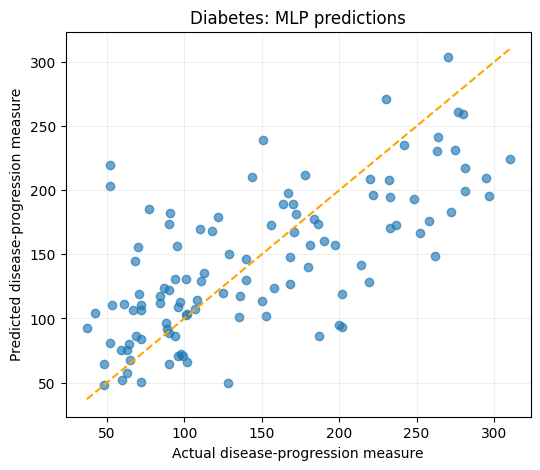

In [13]:
import matplotlib.pyplot as plt

diabetes_mlp_plot_min = min(y_diabetes_test.min(), diabetes_mlp_predictions.min())
diabetes_mlp_plot_max = max(y_diabetes_test.max(), diabetes_mlp_predictions.max())

# Compare MLP predictions with the perfect-prediction reference line.
plt.figure(figsize=(6, 5))
plt.scatter(y_diabetes_test, diabetes_mlp_predictions, alpha=0.65)
plt.plot(
    [diabetes_mlp_plot_min, diabetes_mlp_plot_max],
    [diabetes_mlp_plot_min, diabetes_mlp_plot_max],
    color="orange",
    linestyle="--",
)
plt.xlabel("Actual disease-progression measure")
plt.ylabel("Predicted disease-progression measure")
plt.title("Diabetes: MLP predictions")
plt.grid(alpha=0.2)
plt.show()


### 2.5 Compare the Completed Regression Workflows

This table compares metrics saved after all three models completed their independent workflows. Lower MAE and RMSE are better; higher R-squared is better. A difference on one test partition is evidence for this split, not proof that one method will always perform better.


In [14]:
import pandas as pd

# Compare stored metrics without rebuilding or retraining any model.
diabetes_results = pd.DataFrame(
    [
        {
            "model": "Random Forest",
            "MAE": diabetes_rf_mae,
            "RMSE": diabetes_rf_rmse,
            "R-squared": diabetes_rf_r2,
        },
        {
            "model": "Gradient Boosting",
            "MAE": diabetes_gb_mae,
            "RMSE": diabetes_gb_rmse,
            "R-squared": diabetes_gb_r2,
        },
        {
            "model": "MLP",
            "MAE": diabetes_mlp_mae,
            "RMSE": diabetes_mlp_rmse,
            "R-squared": diabetes_mlp_r2,
        },
    ]
).sort_values("RMSE")

# Identify the lower-RMSE model for this test split without claiming universal superiority.
best_diabetes_model = diabetes_results.iloc[0]["model"]
print(f"Lower test RMSE on this split: {best_diabetes_model}")

diabetes_results.style.format(
    {"MAE": "{:.2f}", "RMSE": "{:.2f}", "R-squared": "{:.3f}"}
)


Lower test RMSE on this split: Random Forest


,model,MAE,RMSE,R-squared
0,Random Forest,42.16,53.14,0.489
2,MLP,41.63,53.62,0.480
1,Gradient Boosting,43.13,55.43,0.444


### 2.6 Interpret the Results Responsibly

MAE describes a typical absolute error in target units, while R-squared estimates how much test-set variation is explained. Scatter around the diagonal reveals individual prediction error. Random Forest reduces variance by averaging many independently varied trees; Gradient Boosting reduces remaining errors sequentially; the MLP learns through weighted hidden layers and may be more sensitive to scaling, architecture and training settings.

**Overall result:** The three models show only moderate predictive performance on this test partition, with R-squared values from 0.444 to 0.489 and RMSE values from 53.14 to 55.43 target units. None provides sufficiently accurate or reliable predictions for clinical decision-making. These models are suitable for demonstrating regression workflows, but their predictions do not support clinical application.

The target is a unitless quantitative measure of disease progression one year after baseline. Higher values indicate greater recorded progression, but the dataset does not provide clinical units or diagnostic thresholds. This small historical teaching dataset does not establish clinical usefulness, fairness or safety; a real health application would require current representative data, clinical validation and ongoing monitoring.


## 3. Case Study — Linnerud Exercise and Physical Measurements Regression

**Problem:** Can three exercise measurements predict Weight, Waist and Pulse together?

This case uses scikit-learn's built-in [Linnerud dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_linnerud.html). Its 20 samples contain three exercise features—Chins, Situps and Jumps—and three continuous physical targets—Weight, Waist and Pulse. Predicting several continuous targets for each sample is **multi-output regression**.


### 3.1 Load and Inspect the Data

With only 20 samples, a single train/test split would make the result highly dependent on a few rows. Leave-one-out cross-validation instead trains on 19 samples and predicts the remaining sample, repeating this process for every row.


In [15]:
import pandas as pd
from sklearn.datasets import load_linnerud

# Load exercise features and physical targets as labelled data frames.
linnerud = load_linnerud(as_frame=True)
X_linnerud = linnerud.data
y_linnerud = linnerud.target

print(f"Samples: {X_linnerud.shape[0]}")
print(f"Exercise features: {list(X_linnerud.columns)}")
print(f"Physical targets: {list(y_linnerud.columns)}")
pd.concat([X_linnerud.head(5), y_linnerud.head(5)], axis=1)


Samples: 20
Exercise features: ['Chins', 'Situps', 'Jumps']
Physical targets: ['Weight', 'Waist', 'Pulse']


,Chins,Situps,Jumps,Weight,Waist,Pulse
0,5.0,162.0,60.0,191.0,36.0,50.0
1,2.0,110.0,60.0,189.0,37.0,52.0
2,12.0,101.0,101.0,193.0,38.0,58.0
3,12.0,105.0,37.0,162.0,35.0,62.0
4,13.0,155.0,58.0,189.0,35.0,46.0


### 3.2 Build and Evaluate a Multi-output Ridge Model

`MultiOutputRegressor` fits one independent Ridge regressor for each target while keeping the construction in one multi-output workflow. `cross_val_predict` returns one out-of-sample prediction for every participant.

**Workflow:** construct → cross-validate → predict → evaluate → inspect.


In [16]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Scale exercise features, then fit one Ridge regressor for each physical target.
linnerud_model = make_pipeline(
    StandardScaler(),
    MultiOutputRegressor(Ridge(alpha=1.0)),
)
linnerud_cv = LeaveOneOut()

# Produce one prediction per sample from a model that did not train on that sample.
linnerud_predictions = cross_val_predict(
    linnerud_model,
    X_linnerud,
    y_linnerud,
    cv=linnerud_cv,
)

# Calculate each target's MAE and R-squared rather than hiding differences in one average.
linnerud_results = pd.DataFrame(
    {
        "target": y_linnerud.columns,
        "MAE": mean_absolute_error(
            y_linnerud, linnerud_predictions, multioutput="raw_values"
        ),
        "R-squared": r2_score(
            y_linnerud, linnerud_predictions, multioutput="raw_values"
        ),
    }
)
linnerud_results.style.format({"MAE": "{:.2f}", "R-squared": "{:.3f}"})


,target,MAE,R-squared
0,Weight,20.03,-0.252
1,Waist,2.08,0.089
2,Pulse,6.76,-0.378


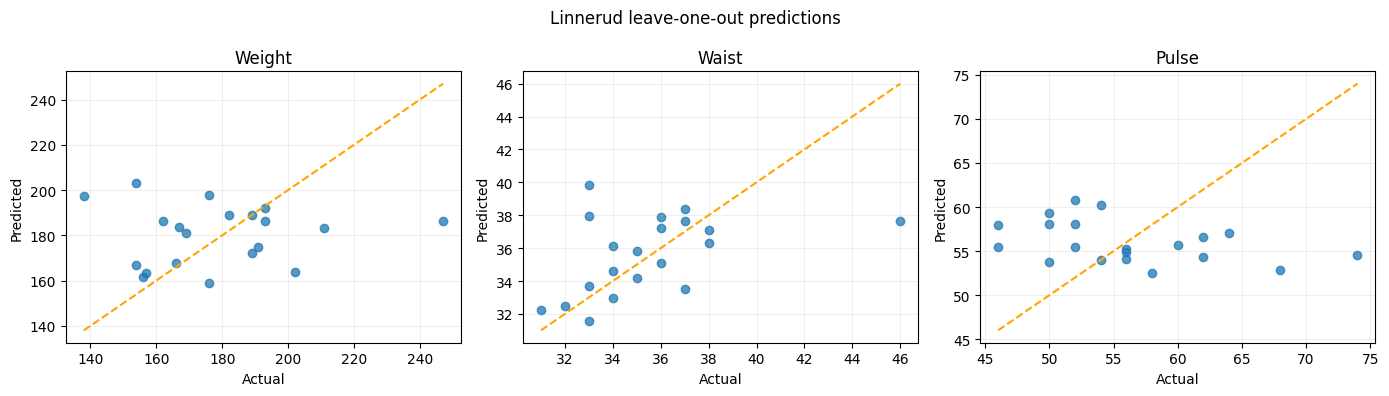

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Inspect leave-one-out predictions separately because each target uses different units.
for target_index, (target_name, axis) in enumerate(zip(y_linnerud.columns, axes)):
    actual_values = y_linnerud.iloc[:, target_index]
    predicted_values = linnerud_predictions[:, target_index]
    plot_min = min(actual_values.min(), predicted_values.min())
    plot_max = max(actual_values.max(), predicted_values.max())

    axis.scatter(actual_values, predicted_values, alpha=0.75)
    axis.plot([plot_min, plot_max], [plot_min, plot_max], color="orange", linestyle="--")
    axis.set_title(target_name)
    axis.set_xlabel("Actual")
    axis.set_ylabel("Predicted")
    axis.grid(alpha=0.2)

plt.suptitle("Linnerud leave-one-out predictions")
plt.tight_layout()
plt.show()


### 3.3 Interpret the Result Responsibly

The three targets have different units, so compare each MAE with that target's observed range rather than comparing MAEs directly across targets. R-squared can be negative when out-of-sample predictions are worse than predicting the target mean. With only 20 historical samples, these results demonstrate multi-output regression and honest evaluation—not a reliable exercise or health assessment tool.


## 4. Case Study — MNIST Digit Classification

Each row contains a digit label followed by 784 pixel values for a `28 × 28` greyscale image. Data preparation creates one balanced classroom subset and one stratified train/test split. Four classifiers then follow separate modelling workflows.


### 4.1 Data Import and Preparation

Pixel values are scaled from `0–255` to `0–1`. Stratification preserves approximately the same proportion of each digit in the subset, training set and test set.


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

MNIST_DATA_PATH = "sample_data/mnist_train_small.csv"
MNIST_SUBSET_SIZE = 3_000
RANDOM_STATE = 42
mnist_columns = ["label"] + [f"pixel_{index}" for index in range(784)]

# Load the local MNIST rows and assign descriptive column names.
mnist = pd.read_csv(MNIST_DATA_PATH, header=None, names=mnist_columns)

# Create a reproducible, stratified subset to keep classroom training times practical.
mnist_subset, _ = train_test_split(
    mnist,
    train_size=MNIST_SUBSET_SIZE,
    stratify=mnist["label"],
    random_state=RANDOM_STATE,
)

# Scale pixel intensity to 0–1 and keep labels as integers.
X_digits = mnist_subset.drop(columns="label").to_numpy(dtype=float) / 255.0
y_digits = mnist_subset["label"].to_numpy(dtype=int)

# Reserve a stratified 20% test partition for every independent classifier workflow.
X_digit_train, X_digit_test, y_digit_train, y_digit_test = train_test_split(
    X_digits,
    y_digits,
    test_size=0.2,
    stratify=y_digits,
    random_state=RANDOM_STATE,
)

print(f"Local MNIST rows: {len(mnist):,}")
print(f"Classroom subset: {len(mnist_subset):,}")
print(f"Training shape: {X_digit_train.shape}")
print(f"Test shape: {X_digit_test.shape}")


Local MNIST rows: 6,000
Classroom subset: 3,000
Training shape: (2400, 784)
Test shape: (600, 784)


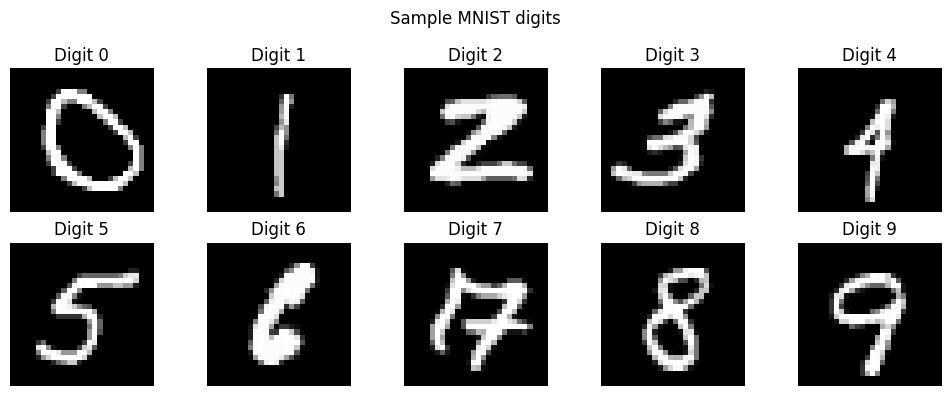

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

# Display one prepared example of each digit before modelling.
for digit, axis in enumerate(axes.flat):
    sample_index = np.flatnonzero(y_digits == digit)[0]
    axis.imshow(X_digits[sample_index].reshape(28, 28), cmap="gray")
    axis.set_title(f"Digit {digit}")
    axis.axis("off")

plt.suptitle("Sample MNIST digits")
plt.tight_layout()
plt.show()


### 4.2 Model 1 — MLP with One Hidden Layer

This neural network uses 64 hidden neurons. Early stopping reserves part of the training data as internal validation data and stops when improvement stalls.

**Workflow:** construct → fit → predict → evaluate.


In [20]:
from time import perf_counter

from sklearn.metrics import accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier

# Construct the first classifier with one 64-neuron hidden layer.
digit_mlp_one = MLPClassifier(
    hidden_layer_sizes=(64,),
    max_iter=35,
    batch_size=128,
    early_stopping=True,
    random_state=RANDOM_STATE,
)

# Time this model's independent fit and prediction workflow.
mlp_one_start = perf_counter()
digit_mlp_one.fit(X_digit_train, y_digit_train)
digit_mlp_one_predictions = digit_mlp_one.predict(X_digit_test)
mlp_one_elapsed = perf_counter() - mlp_one_start

# Accuracy measures overall correctness; macro F1 gives each digit equal weight.
mlp_one_accuracy = accuracy_score(y_digit_test, digit_mlp_one_predictions)
mlp_one_f1 = f1_score(y_digit_test, digit_mlp_one_predictions, average="macro")

print(f"Accuracy: {mlp_one_accuracy:.4f}")
print(f"Macro F1: {mlp_one_f1:.4f}")
print(f"Fit + predict: {mlp_one_elapsed:.2f} seconds")


Accuracy: 0.8967
Macro F1: 0.8966
Fit + predict: 0.31 seconds


### 4.3 Model 2 — MLP with Two Hidden Layers

This model adds a second hidden layer. It may represent more complex patterns, but the extra capacity can also increase computation and overfitting risk.

**Workflow:** construct → fit → predict → evaluate.


In [21]:
from time import perf_counter

from sklearn.metrics import accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier

# Construct a separate classifier with 64-neuron and 32-neuron hidden layers.
digit_mlp_two = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=35,
    batch_size=128,
    early_stopping=True,
    random_state=RANDOM_STATE,
)

# Train and predict without reusing the fitted state of the first MLP.
mlp_two_start = perf_counter()
digit_mlp_two.fit(X_digit_train, y_digit_train)
digit_mlp_two_predictions = digit_mlp_two.predict(X_digit_test)
mlp_two_elapsed = perf_counter() - mlp_two_start

# Evaluate this model's predictions independently.
mlp_two_accuracy = accuracy_score(y_digit_test, digit_mlp_two_predictions)
mlp_two_f1 = f1_score(y_digit_test, digit_mlp_two_predictions, average="macro")

print(f"Accuracy: {mlp_two_accuracy:.4f}")
print(f"Macro F1: {mlp_two_f1:.4f}")
print(f"Fit + predict: {mlp_two_elapsed:.2f} seconds")


Accuracy: 0.8950
Macro F1: 0.8941
Fit + predict: 0.23 seconds


### 4.4 Model 3 — Histogram Gradient Boosting

Histogram gradient boosting builds tree-based learners sequentially. Each stage aims to reduce errors remaining from the current ensemble.

**Workflow:** construct → fit → predict → evaluate.


In [22]:
from time import perf_counter

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

# Limit iterations, leaf nodes and histogram bins for a classroom-sized demonstration.
digit_boosting = HistGradientBoostingClassifier(
    max_iter=12,
    learning_rate=0.12,
    max_leaf_nodes=15,
    max_bins=32,
    random_state=RANDOM_STATE,
)

# Run this tree-based model as its own fit and prediction workflow.
boosting_start = perf_counter()
digit_boosting.fit(X_digit_train, y_digit_train)
digit_boosting_predictions = digit_boosting.predict(X_digit_test)
boosting_elapsed = perf_counter() - boosting_start

# Evaluate only the predictions produced by this boosting model.
boosting_accuracy = accuracy_score(y_digit_test, digit_boosting_predictions)
boosting_f1 = f1_score(y_digit_test, digit_boosting_predictions, average="macro")

print(f"Accuracy: {boosting_accuracy:.4f}")
print(f"Macro F1: {boosting_f1:.4f}")
print(f"Fit + predict: {boosting_elapsed:.2f} seconds")


Accuracy: 0.8800
Macro F1: 0.8789
Fit + predict: 1.88 seconds


### 4.5 Model 4 — K-nearest Neighbours

KNN predicts each test digit from nearby training examples. With `weights="distance"`, closer neighbours contribute more strongly than more distant neighbours.

**Workflow:** construct → fit → predict → evaluate.


In [23]:
from time import perf_counter

from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

# Use three neighbours and weight their votes by distance from the test image.
digit_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance",
)

# Fit and predict as an independent nearest-neighbour workflow.
knn_start = perf_counter()
digit_knn.fit(X_digit_train, y_digit_train)
digit_knn_predictions = digit_knn.predict(X_digit_test)
knn_elapsed = perf_counter() - knn_start

# Evaluate only the digit labels predicted by KNN.
knn_accuracy = accuracy_score(y_digit_test, digit_knn_predictions)
knn_f1 = f1_score(y_digit_test, digit_knn_predictions, average="macro")

print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Macro F1: {knn_f1:.4f}")
print(f"Fit + predict: {knn_elapsed:.2f} seconds")


Accuracy: 0.9050
Macro F1: 0.9042
Fit + predict: 0.04 seconds


### 4.6 Compare the completed classification workflows

The four workflows are compared only after each model has independently completed construction, training, prediction and evaluation. Higher accuracy and macro F1 are better; elapsed time is specific to the computer running the notebook.


In [24]:
# Compare stored metrics without using a loop to build or train models.
digit_results = pd.DataFrame(
    [
        {
            "model": "MLP: one hidden layer",
            "accuracy": mlp_one_accuracy,
            "macro F1": mlp_one_f1,
            "fit + predict (s)": mlp_one_elapsed,
        },
        {
            "model": "MLP: two hidden layers",
            "accuracy": mlp_two_accuracy,
            "macro F1": mlp_two_f1,
            "fit + predict (s)": mlp_two_elapsed,
        },
        {
            "model": "Histogram gradient boosting",
            "accuracy": boosting_accuracy,
            "macro F1": boosting_f1,
            "fit + predict (s)": boosting_elapsed,
        },
        {
            "model": "K-nearest neighbours",
            "accuracy": knn_accuracy,
            "macro F1": knn_f1,
            "fit + predict (s)": knn_elapsed,
        },
    ]
).sort_values("macro F1", ascending=False)

digit_results.style.format(
    {"accuracy": "{:.4f}", "macro F1": "{:.4f}", "fit + predict (s)": "{:.2f}"}
)


,model,accuracy,macro F1,fit + predict (s)
3,K-nearest neighbours,0.9050,0.9042,0.04
0,MLP: one hidden layer,0.8967,0.8966,0.31
1,MLP: two hidden layers,0.8950,0.8941,0.23
2,Histogram gradient boosting,0.8800,0.8789,1.88


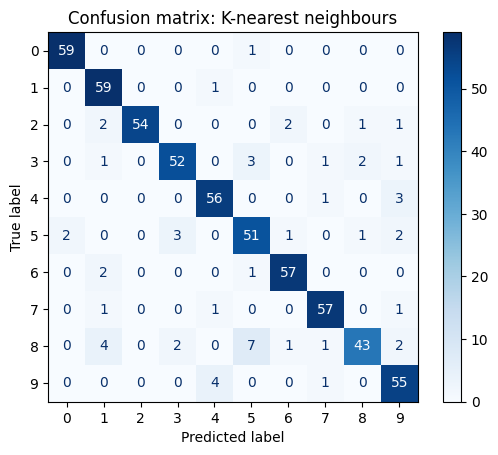

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

# Select the predictions from the highest-macro-F1 completed workflow for error analysis.
best_digit_model_name = digit_results.iloc[0]["model"]
digit_prediction_sets = {
    "MLP: one hidden layer": digit_mlp_one_predictions,
    "MLP: two hidden layers": digit_mlp_two_predictions,
    "Histogram gradient boosting": digit_boosting_predictions,
    "K-nearest neighbours": digit_knn_predictions,
}
best_digit_predictions = digit_prediction_sets[best_digit_model_name]

# Display where the selected model confuses one digit with another.
ConfusionMatrixDisplay.from_predictions(
    y_digit_test,
    best_digit_predictions,
    cmap="Blues",
    values_format="d",
)
plt.title(f"Confusion matrix: {best_digit_model_name}")
plt.show()


## 5. Case Study — Wine Clustering

**Problem:** Can we discover groups of chemically similar wines without giving the clustering method their known cultivar classes?

This case uses scikit-learn's built-in [Wine dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html). It contains 178 samples and 13 positive numeric chemical measurements. The known class is retained only for evaluation after clustering; K-means learns from `X_wine` without a target `y`.

No PCA is used. All clustering uses the 13 standardised original features, and visualisations use selected original measurements.


### 5.1 Load and Inspect the Wine Data

Feature scales differ substantially—for example, `proline` is measured on a much larger numeric scale than several chemical ratios—so standardisation is important before distance-based clustering.


In [26]:
import pandas as pd
from sklearn.datasets import load_wine

WINE_RANDOM_STATE = 42

# Load the built-in feature table and retain known classes for evaluation only.
wine = load_wine(as_frame=True)
X_wine = wine.data
known_wine_class = wine.target

print(f"Samples: {X_wine.shape[0]}")
print(f"Chemical features: {X_wine.shape[1]}")
print(f"Known classes held out from K-means: {known_wine_class.nunique()}")
X_wine.head(3)


Samples: 178
Chemical features: 13
Known classes held out from K-means: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


### 5.2 Select the Number of Clusters

Silhouette score compares cohesion within clusters with separation between clusters. Values closer to `1` indicate clearer separation, values near `0` indicate overlap, and negative values suggest that some samples may fit another cluster better.

We compare `k=2` through `k=6`, then select the highest silhouette score. This is an internal evaluation because it does not use the known Wine classes.


In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Standardise all 13 original chemical measurements before comparing distances.
wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)

wine_k_results = []
for cluster_count in range(2, 7):
    # Fit each candidate with repeated centroid initialisations for stability.
    candidate_model = KMeans(
        n_clusters=cluster_count,
        n_init=20,
        random_state=WINE_RANDOM_STATE,
    )
    candidate_clusters = candidate_model.fit_predict(X_wine_scaled)
    wine_k_results.append(
        {
            "k": cluster_count,
            "silhouette_score": silhouette_score(
                X_wine_scaled,
                candidate_clusters,
            ),
            "inertia": candidate_model.inertia_,
        }
    )

wine_k_results_df = pd.DataFrame(wine_k_results)
best_wine_k = int(
    wine_k_results_df.loc[
        wine_k_results_df["silhouette_score"].idxmax(),
        "k",
    ]
)

print(f"Selected k: {best_wine_k}")
wine_k_results_df.style.format(
    {"silhouette_score": "{:.3f}", "inertia": "{:,.1f}"}
)


Selected k: 3


,k,silhouette_score,inertia
0,2,0.259,"1,658.8"
1,3,0.285,"1,277.9"
2,4,0.259,"1,175.4"
3,5,0.232,"1,107.0"
4,6,0.237,"1,046.0"


### 5.3 Build and Visualise the Final K-means Model

The final model uses all 13 standardised features. The scatter plot shows `alcohol` against `colour_intensity` only so the clusters can be viewed in two dimensions; these two axes are not a PCA projection and do not contain the full clustering information.


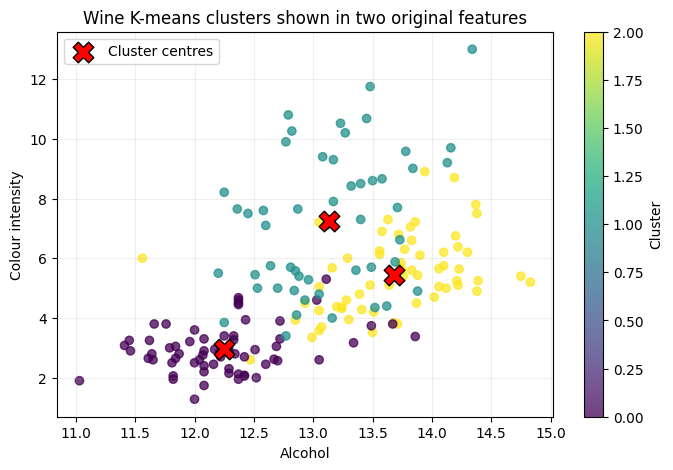

In [28]:
import matplotlib.pyplot as plt

# Fit the selected K-means model using all standardised original features.
wine_cluster_model = KMeans(
    n_clusters=best_wine_k,
    n_init=20,
    random_state=WINE_RANDOM_STATE,
)
wine_clusters = wine_cluster_model.fit_predict(X_wine_scaled)

# Convert cluster centres back to original measurement units for interpretation.
wine_cluster_centres = pd.DataFrame(
    wine_scaler.inverse_transform(wine_cluster_model.cluster_centers_),
    columns=X_wine.columns,
)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_wine["alcohol"],
    X_wine["color_intensity"],
    c=wine_clusters,
    cmap="viridis",
    alpha=0.75,
)
plt.scatter(
    wine_cluster_centres["alcohol"],
    wine_cluster_centres["color_intensity"],
    marker="X",
    s=220,
    c="red",
    edgecolor="black",
    label="Cluster centres",
)
plt.xlabel("Alcohol")
plt.ylabel("Colour intensity")
plt.title("Wine K-means clusters shown in two original features")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### 5.4 Profile and Evaluate the Clusters

Cluster numbers are arbitrary identifiers. We first interpret original-unit centre values, then compare clusters with known classes using adjusted Rand index (ARI). ARI is an external teaching check and was not used to train or select the clusters.


In [29]:
from sklearn.metrics import adjusted_rand_score

# Show selected original-unit measurements that help distinguish the centres.
wine_centre_profile = wine_cluster_centres[
    ["alcohol", "malic_acid", "flavanoids", "color_intensity", "proline"]
].copy()
wine_centre_profile.index.name = "cluster"

# Compare discovered groups with known classes only after clustering is complete.
wine_cluster_class_table = pd.crosstab(
    pd.Series(wine_clusters, name="cluster"),
    pd.Series(known_wine_class.to_numpy(), name="known_class"),
)
wine_adjusted_rand = adjusted_rand_score(known_wine_class, wine_clusters)

print(f"Adjusted Rand index: {wine_adjusted_rand:.3f}")
print("\nCluster versus held-out known class:")
print(wine_cluster_class_table.to_string())
wine_centre_profile.style.format("{:.2f}")


Adjusted Rand index: 0.897

Cluster versus held-out known class:
known_class   0   1   2
cluster                
0             0  65   0
1             0   3  48
2            59   3   0


,alcohol,malic_acid,flavanoids,color_intensity,proline
cluster,,,,,
0,12.25,1.90,2.05,2.97,510.17
1,13.13,3.31,0.82,7.23,619.06
2,13.68,2.00,3.00,5.45,1100.23


**Interpretation:** A strong match with known classes suggests that chemical measurements contain meaningful group structure. A mismatch would not automatically make the clustering wrong because K-means optimises compact distance-based groups, not the historical class definition. The result depends on selected features, scaling, `k` and K-means' preference for roughly compact clusters.
